<a href="https://colab.research.google.com/github/springboardmentor1234r/B13-AirFly-Insights-Internship/blob/Devika_S_Nair/milestone_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AirFly Insights: Data Visualization and Analysis of Airline Operations**

**milestone 2**

**Visual Exploration and Delay Trends**

Univariate and Bivariate Visual Analysis

This part focuses on understanding flight distribution patterns.

In [ ]:
from google.colab import drive
import pandas as pd

# Mounting Google Drive to the default directory
drive.mount('/content/drive')

# accessing the file using its path
file_path = '/content/drive/MyDrive/flights_sample_3m.csv'
df = pd.read_csv(file_path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
!pip install seaborn plotly --quiet+


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --quiet+


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
df = pd.read_parquet("/content/drive/MyDrive/airline_cleaned.parquet")
print(df.shape)
df.head()

(3000000, 36)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,MONTH,DAY_OF_WEEK,DEP_HOUR,ROUTE
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,1065.0,NaN,NaN,NaN,NaN,NaN,1,2,11.0,FLL-EWR
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,1399.0,NaN,NaN,NaN,NaN,NaN,11,5,21.0,MSP-SEA
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,680.0,NaN,NaN,NaN,NaN,NaN,7,4,10.0,DEN-MSP
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,1589.0,0.0,0.0,24.0,0.0,0.0,3,0,16.0,MSP-SFO
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,985.0,NaN,NaN,NaN,NaN,NaN,2,6,18.0,MCO-DFW


**week 3**

• Top airlines, routes, and busiest months


**Top Airlines**

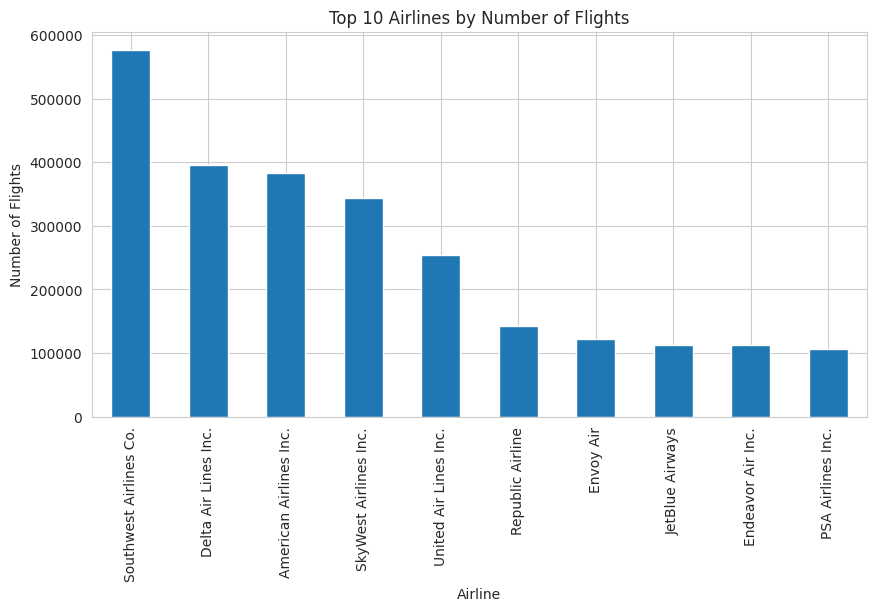

In [ ]:
top_airlines = df['AIRLINE'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_airlines.plot(kind='bar')

plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.show()

**Top Routes**

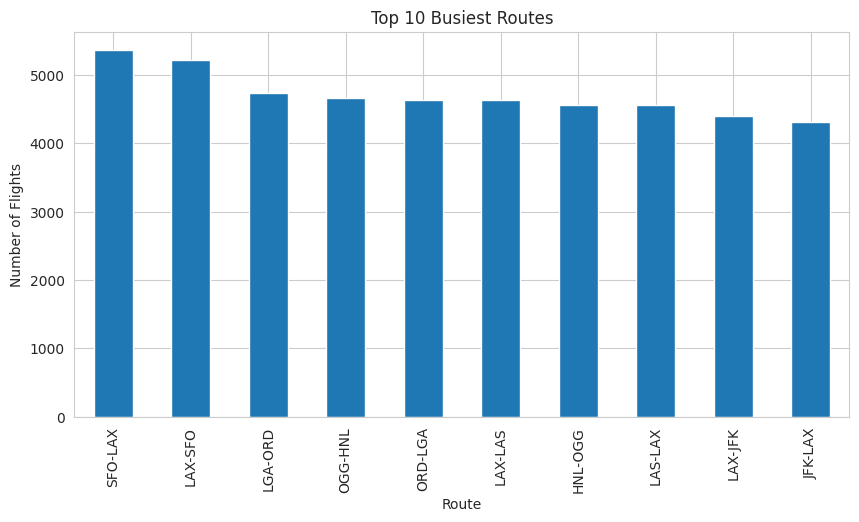

In [ ]:
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_routes.plot(kind='bar')

plt.title("Top 10 Busiest Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.show()

**Busiest Months **

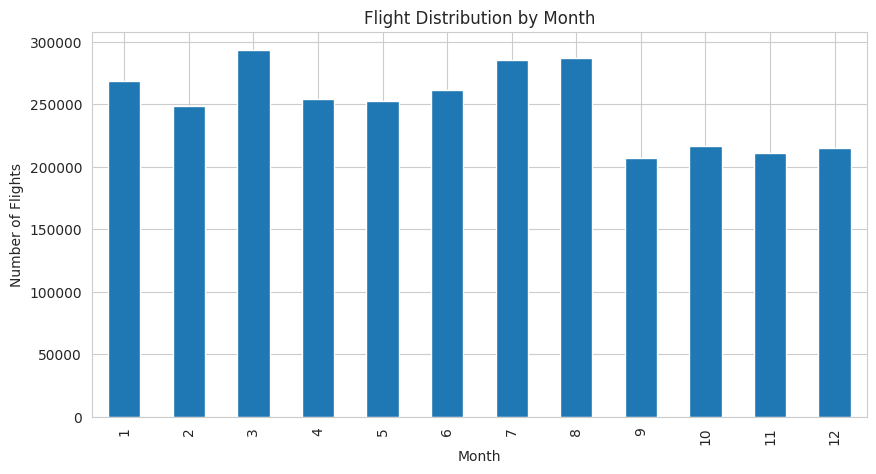

In [ ]:
month_counts = df['MONTH'].value_counts().sort_index()

plt.figure(figsize=(10,5))
month_counts.plot(kind='bar')

plt.title("Flight Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.show()

Flight distribution by day, time, and airport

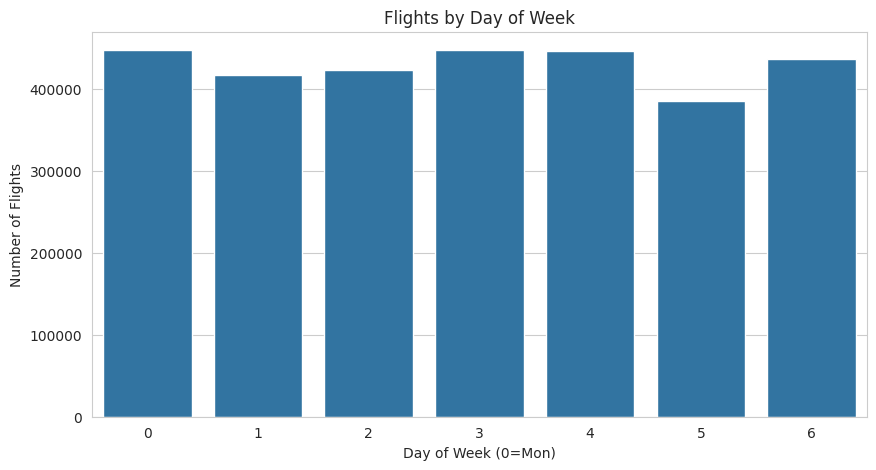

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='DAY_OF_WEEK', data=df)

plt.title("Flights by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Number of Flights")
plt.show()

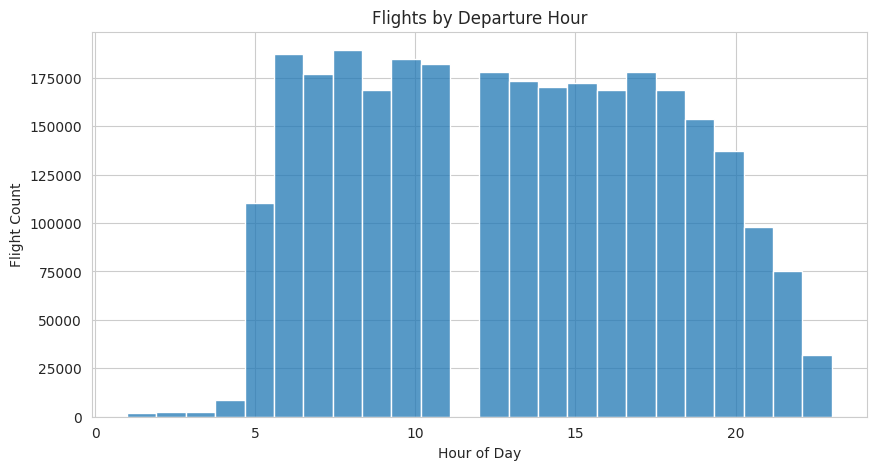

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['DEP_HOUR'], bins=24)

plt.title("Flights by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Flight Count")
plt.show()

week4

Comparing delay causes by airline


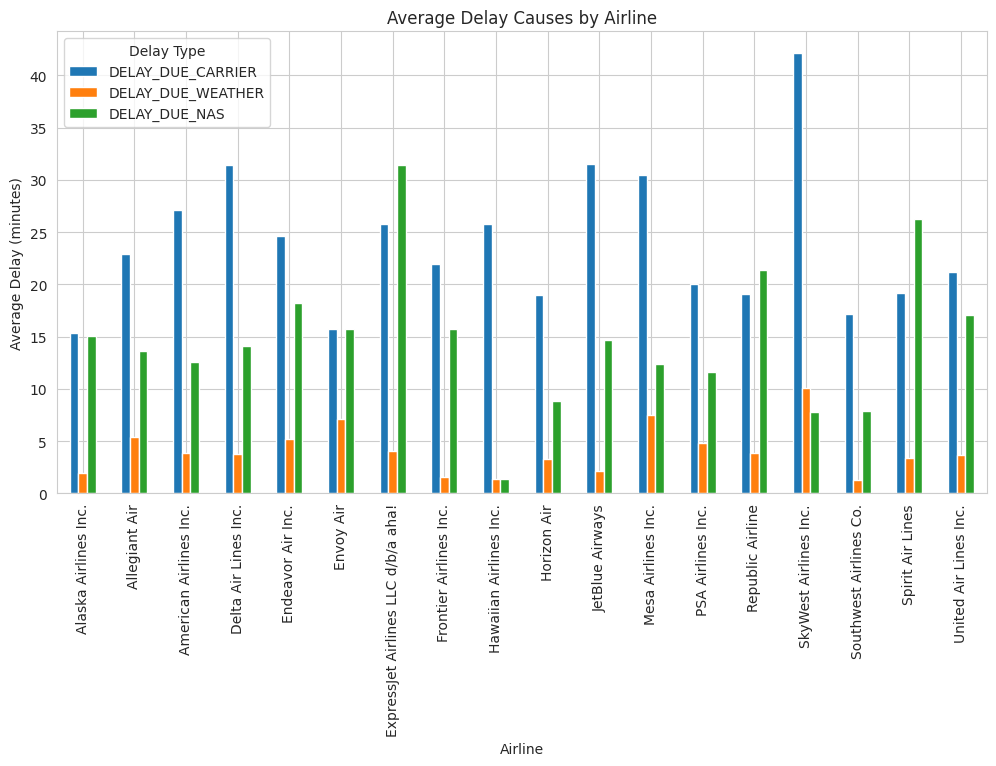

In [ ]:
delay_cols = ['DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS']

alarm_delay = df.groupby('AIRLINE')[delay_cols].mean()

alarm_delay.plot(kind='bar', figsize=(12,6))

plt.title("Average Delay Causes by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay (minutes)")
plt.legend(title="Delay Type")

plt.show()


Exploring carrier delays, weather delays, NAS delays

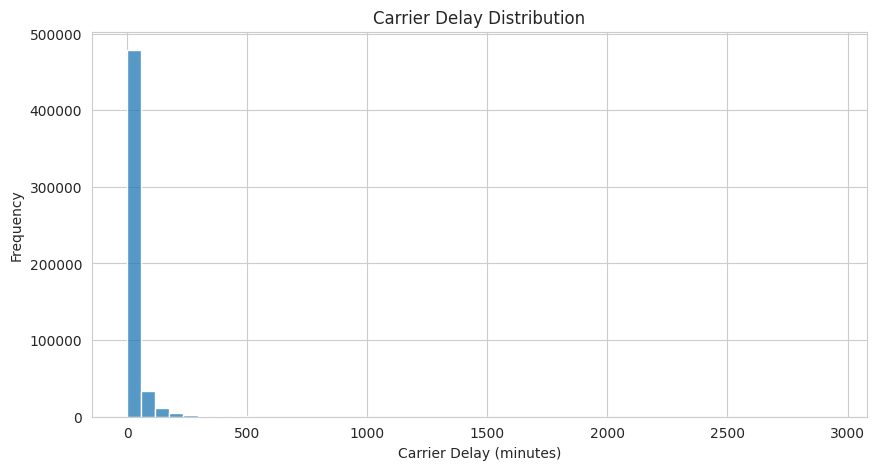

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['DELAY_DUE_CARRIER'], bins=50)

plt.title("Carrier Delay Distribution")
plt.xlabel("Carrier Delay (minutes)")
plt.ylabel("Frequency")

plt.show()

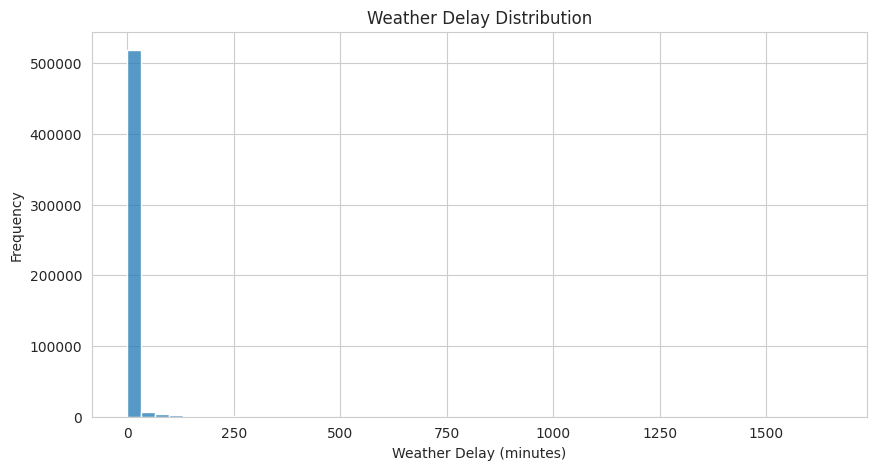

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['DELAY_DUE_WEATHER'], bins=50)

plt.title("Weather Delay Distribution")
plt.xlabel("Weather Delay (minutes)")
plt.ylabel("Frequency")

plt.show()

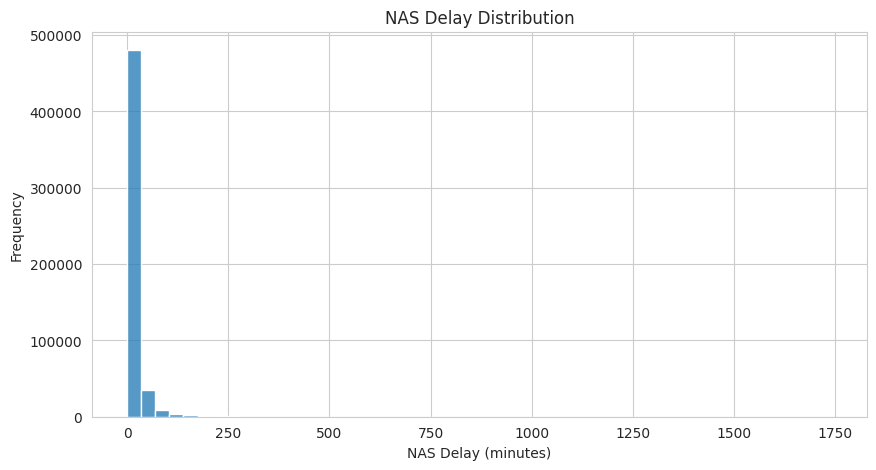

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['DELAY_DUE_NAS'], bins=50)

plt.title("NAS Delay Distribution")
plt.xlabel("NAS Delay (minutes)")
plt.ylabel("Frequency")

plt.show()

Visualizing delays by time of day and airport

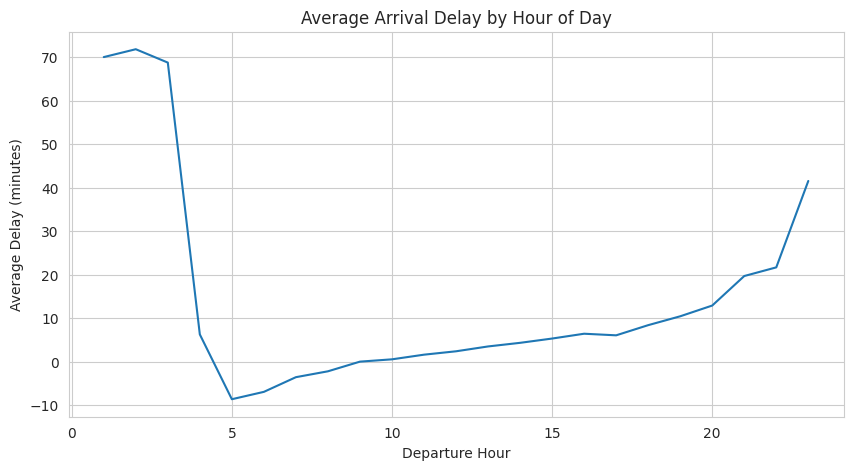

In [ ]:
hour_delay = df.groupby('DEP_HOUR')['ARR_DELAY'].mean()

plt.figure(figsize=(10,5))
hour_delay.plot()

plt.title("Average Arrival Delay by Hour of Day")
plt.xlabel("Departure Hour")
plt.ylabel("Average Delay (minutes)")

plt.show()

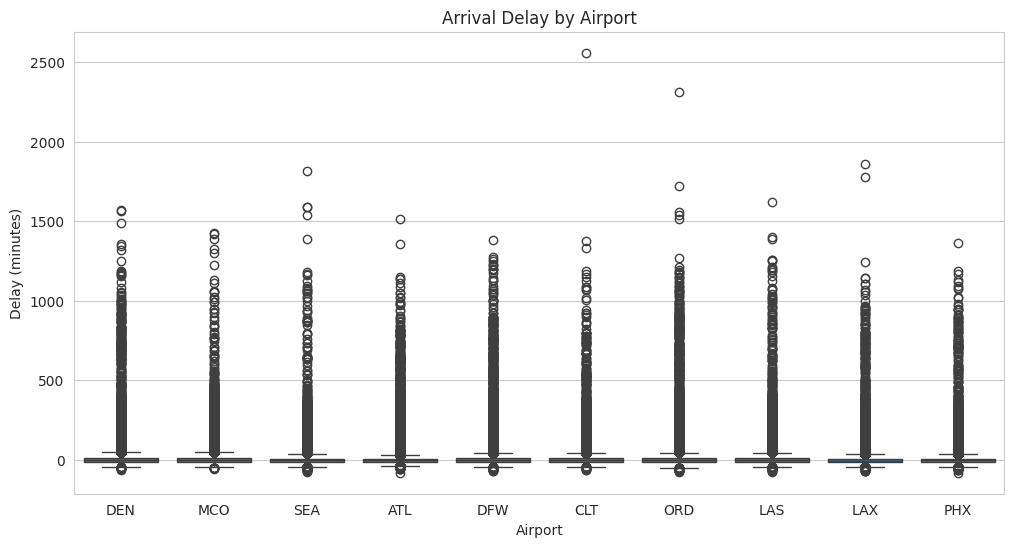

In [ ]:
top_airports = df['ORIGIN'].value_counts().head(10).index
airport_data = df[df['ORIGIN'].isin(top_airports)]

plt.figure(figsize=(12,6))
sns.boxplot(x='ORIGIN', y='ARR_DELAY', data=airport_data)

plt.title("Arrival Delay by Airport")
plt.xlabel("Airport")
plt.ylabel("Delay (minutes)")

plt.show()